# 01 — Data Understanding

**Phase 1: Data Understanding & EDA** · Owner: Ahamed M.A.U (IT24101779) · Group AI-39

This notebook inspects the European Soccer Database before any analysis or modelling. It answers:

1. Which tables exist, how they relate, and which ones are in scope?
2. What does **one row** of the `Match` table represent?
3. What kinds of columns does `Match` contain, and which are usable before kickoff?
4. Which leagues and seasons are covered, and is the coverage complete?
5. What do the `Team` and `Team_Attributes` tables contain, and how well do they line up with matches in time?

Detailed EDA (target distribution, missing values, duplicates, home/away patterns) continues in `02_eda.ipynb`.

## 1. Setup

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.db import DB_PATH, list_tables, load_table, load_matches, load_teams, load_team_attributes

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

FIG_DIR = "../outputs/figures"
print("Database:", DB_PATH.name, f"({DB_PATH.stat().st_size:,} bytes)")

Database: database.sqlite (313,090,048 bytes)


## 2. Tables in the database

The guide asks us to list all tables with `sqlite_master` (§5.1 step 1). `list_tables()` does this and also counts rows and columns.

In [2]:
tables = list_tables()
tables

,table,rows,columns
0,Country,11,2
1,League,11,3
2,Match,25979,115
3,Player,11060,7
4,Player_Attributes,183978,42
5,Team,299,5
6,Team_Attributes,1458,25
7,sqlite_sequence,7,2


| Table | What it holds | In scope? |
|---|---|---|
| `Match` | One row per league fixture: date, season, teams, goals, line-ups, in-match events, betting odds | **Yes**: the unit of analysis and the source of the target |
| `Team` | Team names and IDs | **Yes**: makes matches readable |
| `Team_Attributes` | Dated FIFA-style team tactical ratings | **Yes, conditionally**: only snapshots dated before a match (D-012) |
| `League`, `Country` | Names for `league_id` / `country_id` (11 each) | **Yes**: lookup only |
| `Player`, `Player_Attributes` | Individual player ratings (~184k rows) | **No**, see below |
| `sqlite_sequence` | SQLite internal bookkeeping | No |

**Why the Player tables are out of scope:** our lens is team-level form and home advantage (D-003, D-005). Using
player ratings would mean rebuilding each team's starting XI from the line-up columns, which are themselves partly
missing, and then aligning player-rating snapshots in time. That is a separate project, and it moves away
from the agreed feature set.

## 3. How the tables relate

```
Country (id) ─┐
League  (id) ─┼─< Match >─┬─ home_team_api_id ─┐
              │           └─ away_team_api_id ─┼─> Team (team_api_id) ─< Team_Attributes (team_api_id, date)
              │                                │
              └── country_id / league_id       └─ home_player_1..11 / away_player_1..11 ─> Player (player_api_id)
```

- `Match.home_team_api_id` and `Match.away_team_api_id` both join to `Team.team_api_id`.
- `Team_Attributes` has **many rows per team**, one per snapshot `date`. A match can only use a snapshot dated **on or before** the match (D-012).
- `load_matches()` already joins country, league and team names (§5.1 step 3).

## 4. The `Match` table

In [3]:
matches = load_matches()          # Match + country/league/team names, date parsed
print(matches.shape)
matches.info(verbose=False)

(25979, 119)
<class 'pandas.DataFrame'>
RangeIndex: 25979 entries, 0 to 25978
Columns: 119 entries, id to away_team_name
dtypes: datetime64[us](1), float64(96), int64(9), str(13)
memory usage: 23.6 MB


In [4]:
# Every column is listed with its dtype in the data dictionary; here we summarise the dtype mix
matches.dtypes.astype(str).value_counts()

float64           96
str               13
int64              9
datetime64[us]     1
Name: count, dtype: int64

In [5]:
core_cols = ["season", "stage", "date", "home_team_api_id", "away_team_api_id", "home_team_goal", "away_team_goal"]
matches[core_cols].describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
season,25979,8,2008/2009,3326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stage,25979.0,NaN,NaN,NaN,18.242773,1.0,9.0,18.0,27.0,38.0,10.407354
date,25979,NaN,NaN,NaN,2012-06-30 17:53:53.334616,2008-07-18 00:00:00,2010-05-09 00:00:00,2012-05-13 00:00:00,2014-08-17 00:00:00,2016-05-25 00:00:00,NaN
home_team_api_id,25979.0,NaN,NaN,NaN,9984.371993,1601.0,8475.0,8697.0,9925.0,274581.0,14087.453758
away_team_api_id,25979.0,NaN,NaN,NaN,9984.475115,1601.0,8475.0,8697.0,9925.0,274581.0,14087.445135
home_team_goal,25979.0,NaN,NaN,NaN,1.544594,0.0,1.0,1.0,2.0,10.0,1.297158
away_team_goal,25979.0,NaN,NaN,NaN,1.160938,0.0,0.0,1.0,2.0,9.0,1.14211


### 4.1 What one row represents

Check whether each row is a distinct fixture:

In [6]:
print("id unique:          ", matches["id"].is_unique)
print("match_api_id unique:", matches["match_api_id"].is_unique)
print("team plays itself:  ", (matches["home_team_api_id"] == matches["away_team_api_id"]).sum())

matches[["date", "league_name", "season", "stage", "home_team_name", "away_team_name",
         "home_team_goal", "away_team_goal"]].sort_values("date").head(5)

id unique:           True
match_api_id unique: True
team plays itself:   0


,date,league_name,season,stage,home_team_name,away_team_name,home_team_goal,away_team_goal
24558,2008-07-18,Switzerland Super League,2008/2009,1,BSC Young Boys,FC Basel,1,2
24559,2008-07-19,Switzerland Super League,2008/2009,1,FC Aarau,FC Sion,3,1
24560,2008-07-20,Switzerland Super League,2008/2009,1,FC Luzern,FC Vaduz,1,2
24561,2008-07-20,Switzerland Super League,2008/2009,1,Neuchâtel Xamax,FC Zürich,1,2
24613,2008-07-23,Switzerland Super League,2008/2009,2,AC Bellinzona,Neuchâtel Xamax,1,2


**Row meaning:** one row of `Match` = **one league fixture**: a home team against an away team on a given
date, in a league, season and round (`stage`). `id` and `match_api_id` are both unique, and no team plays itself.
Each match involves two teams, so team-level history features (form, win rates) need a "team-match" long format
where each match contributes two rows (guide §5.3).

### 4.2 Column groups

The 115 raw columns fall into seven groups. The key question for each group is: **is it known before kickoff?**

In [7]:
cols = list(load_matches(with_names=False, parse_dates=False).columns)
position_cols = [c for c in cols if c.startswith(("home_player_X", "home_player_Y", "away_player_X", "away_player_Y"))]
lineup_cols = [f"{side}_player_{i}" for side in ("home", "away") for i in range(1, 12)]
event_cols = ["goal", "shoton", "shotoff", "foulcommit", "card", "cross", "corner", "possession"]
odds_cols = cols[cols.index("B365H"):]

column_groups = {
    "Identifiers": (["id", "match_api_id", "country_id", "league_id", "home_team_api_id", "away_team_api_id"],
                    "Before kickoff", "Keys / joins, not features"),
    "Match context": (["season", "stage", "date"], "Before kickoff", "Chronological ordering, split, features"),
    "Goals": (["home_team_goal", "away_team_goal"], "After the match", "Target source only (D-004, D-010)"),
    "Player positions (X/Y)": (position_cols, "Around kickoff (line-up)", "Not used (team-level lens)"),
    "Line-up player IDs": (lineup_cols, "Around kickoff (line-up)", "Not used (team-level lens)"),
    "In-match events (XML)": (event_cols, "After the match", "Leakage: exclude (D-010)"),
    "Betting odds": (odds_cols, "Before kickoff", "Excluded as features (D-011)"),
}

summary = pd.DataFrame([
    {"group": g, "n_columns": len(c), "avg_%_missing": round(matches[c].isna().mean().mean() * 100, 1),
     "known": known, "role": role, "examples": ", ".join(c[:3])}
    for g, (c, known, role) in column_groups.items()
])
assert summary["n_columns"].sum() == 115
summary

,group,n_columns,avg_%_missing,known,role,examples
0,Identifiers,6,0.0,Before kickoff,"Keys / joins, not features","id, match_api_id, country_id"
1,Match context,3,0.0,Before kickoff,"Chronological ordering, split, features","season, stage, date"
2,Goals,2,0.0,After the match,"Target source only (D-004, D-010)","home_team_goal, away_team_goal"
3,Player positions (X/Y),44,7.0,Around kickoff (line-up),Not used (team-level lens),"home_player_X1, home_player_X2, home_player_X3"
4,Line-up player IDs,22,5.1,Around kickoff (line-up),Not used (team-level lens),"home_player_1, home_player_2, home_player_3"
5,In-match events (XML),8,45.3,After the match,Leakage: exclude (D-010),"goal, shoton, shotoff"
6,Betting odds,30,26.1,Before kickoff,Excluded as features (D-011),"B365H, B365D, B365A"


Observations:

- **Goals** are complete (0% missing), so the target can be built for every match.
- **In-match event columns** (`goal`, `shoton`, `card`, `possession`, …) are about **45% missing** and are only
  known *after* the match. They are leakage by definition, and will be excluded.
- **Betting odds** are about **26% missing** on average. They are excluded as features (D-011); per-bookmaker
  missingness is examined in `02_eda.ipynb`.
- **Line-ups / positions** are 5–7% missing. They are not used because the lens is team-level.

The event columns are stored as raw XML strings, not numbers, so they would need parsing even if they were allowed:

In [8]:
print(matches["goal"].dropna().iloc[0][:300], "...")

<goal><value><comment>n</comment><stats><goals>1</goals><shoton>1</shoton></stats><event_incident_typefk>406</event_incident_typefk><elapsed>22</elapsed><player2>38807</player2><subtype>header</subtype><player1>37799</player1><sortorder>5</sortorder><team>10261</team><id>378998</id><n>295</n><type>g ...


## 5. Coverage: leagues and seasons

In [9]:
print("Date range:", matches["date"].min().date(), "to", matches["date"].max().date())
print("Leagues:", matches["league_name"].nunique(), "| Seasons:", matches["season"].nunique(),
      "| Teams:", pd.concat([matches["home_team_api_id"], matches["away_team_api_id"]]).nunique())

coverage = matches.pivot_table(index="league_name", columns="season", values="id", aggfunc="count")
coverage

Date range: 2008-07-18 to 2016-05-25
Leagues: 11 | Seasons: 8 | Teams: 299


season,2008/2009,2009/2010,2010/2011,2011/2012,2012/2013,2013/2014,2014/2015,2015/2016
league_name,,,,,,,,
Belgium Jupiler League,306,210,240,240,240,12,240,240
England Premier League,380,380,380,380,380,380,380,380
France Ligue 1,380,380,380,380,380,380,380,380
Germany 1. Bundesliga,306,306,306,306,306,306,306,306
Italy Serie A,380,380,380,358,380,380,379,380
Netherlands Eredivisie,306,306,306,306,306,306,306,306
Poland Ekstraklasa,240,240,240,240,240,240,240,240
Portugal Liga ZON Sagres,240,240,240,240,240,240,306,306
Scotland Premier League,228,228,228,228,228,228,228,228


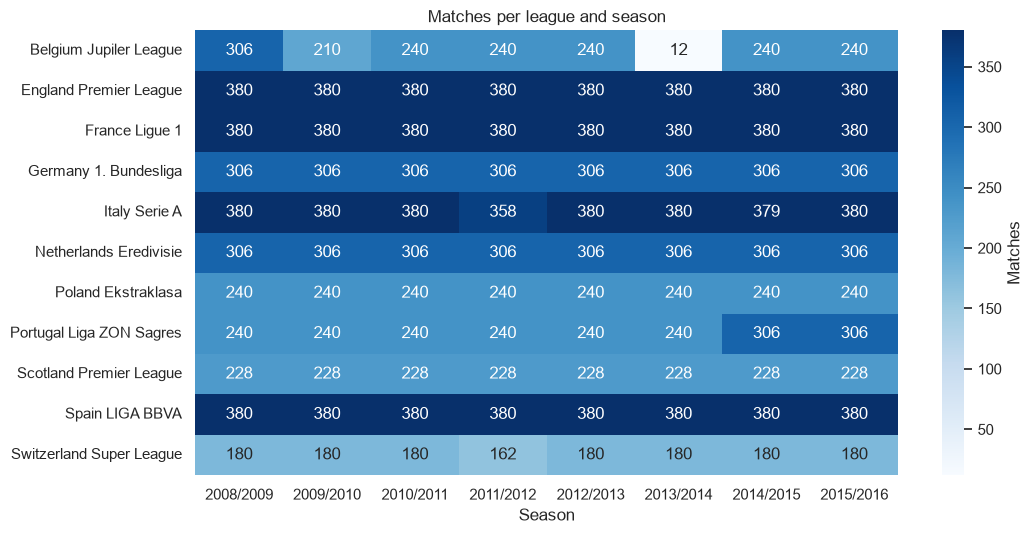

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(coverage, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "Matches"}, ax=ax)
ax.set_title("Matches per league and season")
ax.set_xlabel("Season")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_01_matches_by_league_season.png", dpi=150)
plt.show()

Compare each league-season with the number of fixtures a full season should have (each team plays every other team home and away):

In [11]:
teams_per_league_season = (
    pd.concat([
        matches[["league_name", "season", "home_team_api_id"]].rename(columns={"home_team_api_id": "team"}),
        matches[["league_name", "season", "away_team_api_id"]].rename(columns={"away_team_api_id": "team"}),
    ])
    .groupby(["league_name", "season"])["team"].nunique()
)
check = pd.DataFrame({
    "teams": teams_per_league_season,
    "matches": matches.groupby(["league_name", "season"]).size(),
})
check["expected_double_round_robin"] = check["teams"] * (check["teams"] - 1)
check["difference"] = check["matches"] - check["expected_double_round_robin"]
check[(check["difference"] != 0) | (check["matches"] < 100)]

teams  matches  expected_double_round_robin  difference
league_name              season                                                            
Belgium Jupiler League   2013/2014      4       12                           12           0
Italy Serie A            2011/2012     20      358                          380         -22
                         2014/2015     20      379                          380          -1
Scotland Premier League  2008/2009     12      228                          132          96
                         2009/2010     12      228                          132          96
                         2010/2011     12      228                          132          96
                         2011/2012     12      228                          132          96
                         2012/2013     12      228                          132          96
                         2013/2014     12      228                          132          96
                         2014/2015     12      228                          132          96
                         2015/2016     12      228                          132          96
Switzerland Super League 2008/2009     10      180                           90          90
                         2009/2010     10      180                           90          90
                         2010/2011     10      180                           90          90
                         2011/2012     10      162                           90          72
                         2012/2013     10      180                           90          90
                         2013/2014     10      180                           90          90
                         2014/2015     10      180                           90          90
                         2015/2016     10      180                           90          90

**Coverage findings:**

- 25,979 matches · 11 leagues · 8 seasons (2008/09 – 2015/16) · 299 teams.
- **Belgium Jupiler League 2013/2014 has only 12 matches** (normally 240), so that season is almost entirely missing.
  It passes the round-robin check only because those 12 matches involve just 4 teams (4 × 3 = 12). Belgian teams
  will have a large hole in their match history, and rolling "last 5" form early in 2014/15 would reach back to
  matches from more than a year earlier.
- **Belgium 2009/10** has 210 matches from 15 teams (15 × 14 = 210), which is internally consistent. A club
  dropping out mid-season fits with the Mouscron ID change discussed in Section 6.
- **Italy Serie A 2011/12** has 358 matches (22 short) and **2014/15** has 379 (1 short). **Switzerland 2011/12** has 162
  (18 short). These are small gaps.
- **Scotland** (12 teams, 228 matches) and **Switzerland** (10 teams, 180 matches) show a positive difference because
  teams meet each other more than twice. That is how those leagues are designed, not duplication. **Portugal** grows
  from 16 to 18 teams in 2014/15.
- Seasons run July → May/June, so a chronological split by season is natural (D-009).

## 6. The `Team` table

In [12]:
teams = load_teams()
print(teams.shape)
teams.info()
teams.head()

(299, 5)
<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                299 non-null    int64  
 1   team_api_id       299 non-null    int64  
 2   team_fifa_api_id  288 non-null    float64
 3   team_long_name    299 non-null    str    
 4   team_short_name   299 non-null    str    
dtypes: float64(1), int64(2), str(2)
memory usage: 11.8 KB


,id,team_api_id,team_fifa_api_id,team_long_name,team_short_name
0,1,9987,673.0,KRC Genk,GEN
1,2,9993,675.0,Beerschot AC,BAC
2,3,10000,15005.0,SV Zulte-Waregem,ZUL
3,4,9994,2007.0,Sporting Lokeren,LOK
4,5,9984,1750.0,KSV Cercle Brugge,CEB


In [13]:
print("Missing team_fifa_api_id:", teams["team_fifa_api_id"].isna().sum())
print("Duplicate team_api_id:  ", teams["team_api_id"].duplicated().sum())
print("Duplicate team names:   ", teams["team_long_name"].duplicated().sum())
teams[teams["team_long_name"].duplicated(keep=False)]

Missing team_fifa_api_id: 11
Duplicate team_api_id:   0
Duplicate team names:    3


,id,team_api_id,team_fifa_api_id,team_long_name,team_short_name
15,16,9996,111560.0,Royal Excel Mouscron,MOU
24,2510,274581,111560.0,Royal Excel Mouscron,MOP
182,31444,8031,111429.0,Polonia Bytom,POB
183,31445,8020,111429.0,Polonia Bytom,GOR
189,31451,8244,301.0,Widzew Łódź,LOD
199,32409,8024,301.0,Widzew Łódź,WID


`team_api_id` is unique and is the key we use. Three names are shared by two IDs each, and each pair also shares a
`team_fifa_api_id`. Are they one club under two IDs, or two clubs under one name? If the two IDs ever played
each other, they must be different clubs:

In [14]:
dup_ids = teams[teams["team_long_name"].duplicated(keep=False)].groupby("team_long_name")["team_api_id"].apply(list)
rows = []
for name, (a, b) in dup_ids.items():
    def seasons(t):
        return sorted(matches.loc[(matches["home_team_api_id"] == t) | (matches["away_team_api_id"] == t), "season"].unique())
    h2h = (((matches["home_team_api_id"] == a) & (matches["away_team_api_id"] == b)) |
           ((matches["home_team_api_id"] == b) & (matches["away_team_api_id"] == a))).sum()
    rows.append({"team_long_name": name, "ids": (a, b), "seasons_id_1": seasons(a), "seasons_id_2": seasons(b),
                 "matches_against_each_other": h2h})
pd.DataFrame(rows)

,team_long_name,ids,seasons_id_1,seasons_id_2,matches_against_each_other
0,Polonia Bytom,"(8031, 8020)","[2008/2009, 2009/2010, 2010/2011]","[2008/2009, 2010/2011, 2011/2012, 2012/2013, 2...",4
1,Royal Excel Mouscron,"(9996, 274581)",[2008/2009],"[2014/2015, 2015/2016]",0
2,Widzew Łódź,"(8244, 8024)","[2008/2009, 2011/2012]","[2010/2011, 2011/2012, 2012/2013, 2013/2014]",2


- **Polonia Bytom** and **Widzew Łódź**: each pair of IDs **played each other**, so they are two different clubs
  that the `Team` table labels with the same name and FIFA ID. This is a **labelling error** in the source data.
  The short names (`GOR`, `LOD`) suggest the second club in each pair is really a different Polish club.
- **Royal Excel Mouscron**: the two IDs never overlap (2008/09 vs 2014/15 onwards). This is consistent with the
  original club folding and a successor club taking the name. Treating them as separate teams is reasonable.
- **Implication:** team names are unreliable for grouping. **Always group by `team_api_id`.** Grouping by name would
  merge two different Polish clubs' histories and corrupt their form features.

## 7. The `Team_Attributes` table

In [15]:
team_attrs = load_team_attributes()
print(team_attrs.shape)
team_attrs.info()

(1458, 25)
<class 'pandas.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              1458 non-null   int64         
 1   team_fifa_api_id                1458 non-null   int64         
 2   team_api_id                     1458 non-null   int64         
 3   date                            1458 non-null   datetime64[us]
 4   buildUpPlaySpeed                1458 non-null   int64         
 5   buildUpPlaySpeedClass           1458 non-null   str           
 6   buildUpPlayDribbling            489 non-null    float64       
 7   buildUpPlayDribblingClass       1458 non-null   str           
 8   buildUpPlayPassing              1458 non-null   int64         
 9   buildUpPlayPassingClass         1458 non-null   str           
 10  buildUpPlayPositioningClass     1458 non-null   str           
 11  chan

In [16]:
team_attrs.describe().T

,count,mean,min,25%,50%,75%,max,std
id,1458.0,729.5,1.0,365.25,729.5,1093.75,1458.0,421.032659
team_fifa_api_id,1458.0,17706.982167,1.0,110.0,485.0,1900.0,112513.0,39179.857739
team_api_id,1458.0,9995.727023,1601.0,8457.75,8674.0,9904.0,274581.0,13264.8699
date,1458,2012-12-06 22:40:59.259259,2010-02-22 00:00:00,2011-02-22 00:00:00,2013-09-20 00:00:00,2014-09-19 00:00:00,2015-09-10 00:00:00,NaN
buildUpPlaySpeed,1458.0,52.462277,20.0,45.0,52.0,62.0,80.0,11.545869
buildUpPlayDribbling,489.0,48.607362,24.0,42.0,49.0,55.0,77.0,9.67829
buildUpPlayPassing,1458.0,48.490398,20.0,40.0,50.0,55.0,80.0,10.896101
chanceCreationPassing,1458.0,52.165295,21.0,46.0,52.0,59.0,80.0,10.360793
chanceCreationCrossing,1458.0,53.731824,20.0,47.0,53.0,62.0,80.0,11.086796
chanceCreationShooting,1458.0,53.969136,22.0,48.0,53.0,61.0,80.0,10.327566


Each tactical dimension appears twice: as a numeric rating (e.g. `buildUpPlaySpeed`, 20–80) and as a category
(e.g. `buildUpPlaySpeedClass` = Slow / Balanced / Fast). The categories are bins of the numbers, so we would use
only one of each pair. Some dimensions (`buildUpPlayPositioningClass`, `chanceCreationPositioningClass`,
`defenceDefenderLineClass`) only exist as categories.

In [17]:
print("Snapshot dates:")
print(team_attrs["date"].value_counts().sort_index())

match_teams = set(matches["home_team_api_id"]) | set(matches["away_team_api_id"])
print("\nTeams with any attributes:", team_attrs["team_api_id"].nunique(), "of", len(match_teams))
print("Missing buildUpPlayDribbling:", team_attrs["buildUpPlayDribbling"].isna().sum(), "of", len(team_attrs))

first_snapshot = team_attrs["date"].min()
before = (matches["date"] < first_snapshot).sum()
print(f"\nMatches before the first snapshot ({first_snapshot.date()}): {before:,} ({before / len(matches):.1%})")

Snapshot dates:
date
2010-02-22    241
2011-02-22    244
2012-02-22    242
2013-09-20    242
2014-09-19    244
2015-09-10    245
Name: count, dtype: int64

Teams with any attributes: 288 of 299
Missing buildUpPlayDribbling: 969 of 1458

Matches before the first snapshot (2010-02-22): 5,469 (21.1%)


In [18]:
# How many matches can join a snapshot dated on or before the match for BOTH teams (rule D-012)?
attrs_sorted = team_attrs[["team_api_id", "date"]].rename(columns={"date": "attr_date"}).sort_values("attr_date")
m = matches[["id", "date", "home_team_api_id", "away_team_api_id"]].sort_values("date")

for side in ("home", "away"):
    m = pd.merge_asof(m, attrs_sorted.rename(columns={"team_api_id": f"{side}_team_api_id",
                                                     "attr_date": f"{side}_attr_date"}),
                      left_on="date", right_on=f"{side}_attr_date", by=f"{side}_team_api_id",
                      direction="backward")

both = m["home_attr_date"].notna() & m["away_attr_date"].notna()
print(f"Matches with a valid prior snapshot for both teams: {both.sum():,} ({both.mean():.1%})")
print("By season:")
print(both.groupby(matches.set_index("id").loc[m["id"], "season"].values).mean().round(3))

Matches with a valid prior snapshot for both teams: 19,355 (74.5%)
By season:
2008/2009    0.000
2009/2010    0.337
2010/2011    0.935
2011/2012    0.956
2012/2013    0.931
2013/2014    0.938
2014/2015    0.931
2015/2016    0.953
dtype: float64


**Team_Attributes findings:**

- 1,458 rows covering 288 of the 299 teams, taken on **six snapshot dates** (Feb 2010, 2011, 2012; Sep 2013, 2014, 2015).
- The first snapshot is **2010-02-22**, so every match before that, **5,469 (21%)** covering all of 2008/09 and half of
  2009/10, has **no valid attributes** under D-012.
- Snapshots are about a year apart, so a match uses ratings that may be up to ~19 months old.
- `buildUpPlayDribbling` is missing in **969 of 1,458 rows (66%)**; it is effectively only filled from the 2014 snapshot on.
- Joining the latest snapshot on or before each match gives valid attributes for both teams in **74.5%** of matches:
  **0%** in 2008/09, **34%** in 2009/10, and about **93–96%** from 2010/11 on. The rest comes from the 11 teams with no
  attributes at all, and from promoted teams first rated after their first matches.
- **Implication:** Team_Attributes can only be an *optional* extra feature group, with missing values for early
  matches. The core features should come from match history (form, goals, home/away win rates), which covers
  every season.

## 8. Summary and handoffs

| # | Finding | Why it matters for modelling | Goes to |
|---|---|---|---|
| 1 | One `Match` row = one fixture; `id` / `match_api_id` unique | The unit of analysis; team features need a 2-rows-per-match long format | Umair |
| 2 | Goals complete for all 25,979 matches | The target can be built for every match with no imputation | Umair, Yusuf |
| 3 | 8 in-match event columns are XML, about 45% missing and post-match | Leakage: drop from features (D-010) | Umair |
| 4 | 30 odds columns, about 26% missing | Not features (D-011); document only | Umair |
| 5 | Line-up / X-Y columns (66) are player-level | Out of the team-level scope; drop | Umair |
| 6 | Belgium 2013/14 has only 12 of ~240 matches | Gap in Belgian team histories; rolling form spans the gap | Umair, Yusuf |
| 7 | Team_Attributes starts 2010-02-22; only 74.5% of matches have a valid prior snapshot for both teams (0% in 2008/09) | Optional feature group only; core features from match history | Umair |
| 8 | `buildUpPlayDribbling` 66% missing | Drop that attribute if Team_Attributes is used | Umair |
| 9 | 3 team names are shared by two IDs; two Polish pairs are different clubs that played each other | Always group by `team_api_id`, never by name, or form histories get merged | Everyone |
| 10 | Seasons run Jul → May, 8 complete seasons | Natural chronological split by season (D-009) | Yusuf |

These findings are written up as entries in `logs/eda_insight_log.md`. Missing values, duplicates, the target
distribution and home/away patterns are analysed in **`02_eda.ipynb`**.